# How does DVA differ between measurements

In [40]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustnesss')[0], "EV_DVA_Robustnesss"))
from src.config_base import GeneralConfig

In [41]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [42]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

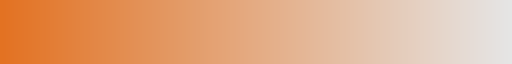

In [43]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 3))
tum_orange_cmap

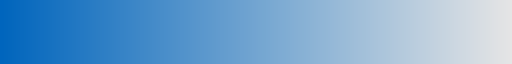

In [44]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

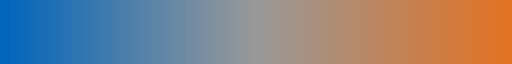

In [45]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
colors = tum_cmap(np.linspace(1,0, 5))
tum_cmap

In [46]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [47]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [48]:
read_feather = ReadFeather()

In [49]:
%%capture
df_vw_213_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_204_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_204_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)
df_vw_349_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_349_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_397_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_397_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)

In [50]:
read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

## CU Data VW

In [51]:
%%capture
df_vw_213 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 
df_vw_204 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_204_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 
df_vw_288 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000)
df_vw_349 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_349_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 
df_vw_397 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_397_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000)

In [52]:
print(round(df_vw_213.E.max()/58*100,1))
print(round(df_vw_204.E.max()/58*100,1))
print(round(df_vw_288.E.max()/58*100,1))
print(round(df_vw_349.E.max()/58*100,1))
print(round(df_vw_397.E.max()/58*100,1))

106.3
105.5
106.1
105.1
105.9


In [53]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [54]:
Q_vw_213_370V = df_vw_213.Q[np.argmin(np.abs(df_vw_213.U-370))]
Q_vw_204_370V = df_vw_204.Q[np.argmin(np.abs(df_vw_204.U-370))]
Q_vw_288_370V = df_vw_288.Q[np.argmin(np.abs(df_vw_288.U-370))]
Q_vw_349_370V = df_vw_349.Q[np.argmin(np.abs(df_vw_349.U-370))]
Q_vw_397_370V = df_vw_397.Q[np.argmin(np.abs(df_vw_397.U-370))]

In [55]:
Q_vw_213_450V = df_vw_213.Q[np.argmin(np.abs(df_vw_213.U-450))]
Q_vw_204_450V = df_vw_204.Q[np.argmin(np.abs(df_vw_204.U-450))]
Q_vw_288_450V = df_vw_288.Q[np.argmin(np.abs(df_vw_288.U-450))]
Q_vw_349_450V = df_vw_349.Q[np.argmin(np.abs(df_vw_349.U-450))]
Q_vw_397_450V = df_vw_397.Q[np.argmin(np.abs(df_vw_397.U-450))]

In [56]:
Q_vw_213_450V-Q_vw_213_370V

143.63422301592638

In [57]:
Q_vw_204_450V-Q_vw_204_370V

141.46592948256182

In [58]:
Q_vw_288_450V-Q_vw_288_370V

143.08435562867234

In [59]:
Q_vw_349_450V-Q_vw_349_370V

144.40020729544656

In [60]:
Q_vw_397_450V-Q_vw_397_370V

141.86982065095094

In [61]:
np.mean([Q_vw_213_450V-Q_vw_213_370V,Q_vw_204_450V-Q_vw_204_370V,Q_vw_288_450V-Q_vw_288_370V,Q_vw_349_450V-Q_vw_349_370V,Q_vw_397_450V-Q_vw_397_370V])

142.8909072147116

In [62]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [63]:
dva_vw_213, cap_vw_213 = dva_extractor.get_dva(time=df_vw_213["time_h"], capacity=df_vw_213["Q"], voltage=df_vw_213["U"],crop_cap_Ah=(0,180))
dva_vw_204, cap_vw_204 = dva_extractor.get_dva(time=df_vw_204["time_h"], capacity=df_vw_204["Q"], voltage=df_vw_204["U"],crop_cap_Ah=(0,180))
dva_vw_288, cap_vw_288 = dva_extractor.get_dva(time=df_vw_288["time_h"], capacity=df_vw_288["Q"], voltage=df_vw_288["U"],crop_cap_Ah=(0,180))
dva_vw_349, cap_vw_349 = dva_extractor.get_dva(time=df_vw_349["time_h"], capacity=df_vw_349["Q"], voltage=df_vw_349["U"],crop_cap_Ah=(0,180))
dva_vw_397, cap_vw_397 = dva_extractor.get_dva(time=df_vw_397["time_h"], capacity=df_vw_397["Q"], voltage=df_vw_397["U"],crop_cap_Ah=(0,180))

## Plot

In [64]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=colors,remove_tick_ind=None):    
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')
    
    width = 0.4 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=6,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,1.85])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=6)
    axes.yaxis.set_label_coords(0.13,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

In [65]:
def plot_pOCV_vw(axes, lst_dfs,lst_Q):
    color_ind =[0,1,2,3,4]
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)

    axes.scatter([0,143],[370,450],s=25,marker="*",color="k",zorder=3)
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([-10,160])
    tick_positions = np.array([-10,0,40,80,120,160])
    axes.set_xticks(tick_positions)
    _ = [x.set_horizontalalignment("right") for x in axes.get_xticklabels()[0:1]]
    axes.set_ylim([360,460])
    tick_positions = np.array([360,370,390,410,430,450,460])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.axhline(y=450, xmin=0, xmax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axhline(y=370, xmin=0, xmax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=0, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=143, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    
    # kWh Axes
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy (aligned) in kWh",fontsize=9) 
    twiny.set_xlim(-10,160)
    tick_positions = np.array([-10,0,40,80,120,160])
    twiny.set_xticks(tick_positions)
    #_ = [x.set_horizontalalignment("right") for x in twiny.get_xticklabels()[0:1]]
    twiny.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])
    # close up 1
    axins = axes.inset_axes([45, 364,30,25],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_dfs):
        axins.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)
    axins.scatter([0,143],[370,450],s=25,marker="*",color="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = -5, 2, 358,373
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='A', xy=(-4.85,368), xytext=(-4.85,368),fontsize=9)
    # close up 2
    axins = axes.inset_axes([110, 395,30,25],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_dfs):
        axins.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)
    axins.scatter([0,143],[370,450],s=25,marker="*",color="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 140, 149, 448, 455
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='B', xy=(140.3,452.6), xytext=(140.3,452.6),fontsize=9)

    #insert axes right
    E_nom_VW = 58
    axins = axes.inset_axes([2, 412,60,36],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1,2,3,4],y1=np.hstack(np.array([df_vw_213_E.E.max(),df_vw_204_E.E.max(),df_vw_288_E.E.max(),df_vw_349_E.E.max(),df_vw_397_E.E.max()])/E_nom_VW*100))
    return axes

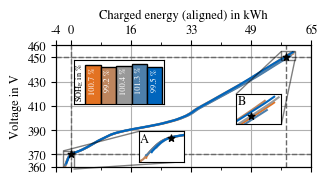

In [66]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
axes = plot_pOCV_vw(axes,lst_dfs = [df_vw_213,df_vw_204,df_vw_288,df_vw_349,df_vw_397],lst_Q = [Q_vw_213_370V,Q_vw_204_370V,Q_vw_288_370V,Q_vw_349_370V,Q_vw_397_370V])

In [67]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [68]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [69]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva, lst_Q):
    color_ind =[0,1,2,3,4]
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        #axes.scatter(xpos-lst_Q[ind],ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=3)

        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=115,Q_max=145)
        maxDVA = np.argmax(yDVA)
        #axes.scatter(xcap[maxDVA]-lst_Q[ind],yDVA[maxDVA],marker="o",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
   
    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity (aligned) in Ah",fontsize=9) 
    axes.set_xlim([-10,160])
    tick_positions = np.array([-10,0,40,80,120,160])
    axes.set_xticks(tick_positions)
    _ = [x.set_horizontalalignment("right") for x in axes.get_xticklabels()[0:1]]
   
    axes.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)

    axes.annotate(text='A', xy=(8,74), xytext=(17,59),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    axes.axvline(x=0, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=143, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    twiny = axes.twiny() 
    twiny.set_xlim(-10,160)
    tick_positions = np.array([-10,0,40,80,120,160])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])

    # close up 1
    axins = axes.inset_axes([34, 80,35,70],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axins.scatter(xpos-lst_Q[ind],ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 75, 90, 98,152
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='B', xy=(75.25,140), xytext=(75.25,140),fontsize=9)
    # close up 2
    axins = axes.inset_axes([85, 15,55,60],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=115,Q_max=145)
        maxDVA = np.argmax(yDVA)
        axins.scatter(xcap[maxDVA]-lst_Q[ind],yDVA[maxDVA],marker="o",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 110, 143, 105, 135
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='C', xy=(111,127), xytext=(111,127),fontsize=9)
    return axes

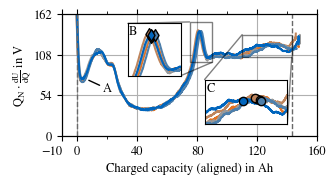

In [70]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
axes = plot_dva_vw(axes,
                    lst_cap = [cap_vw_213,cap_vw_204,cap_vw_288,cap_vw_349,cap_vw_397],
                    lst_dva = [dva_vw_213,dva_vw_204,dva_vw_288,dva_vw_349,dva_vw_397],
                    lst_Q = [Q_vw_213_370V,Q_vw_204_370V,Q_vw_288_370V,Q_vw_349_370V,Q_vw_397_370V])

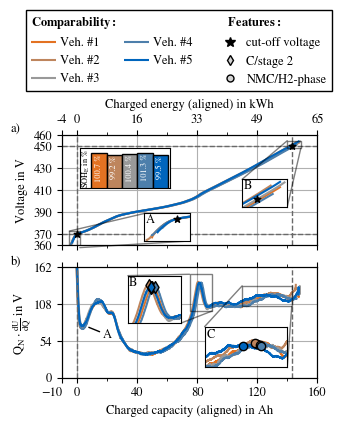

In [71]:
n_rows = 2
heigth = 4 #cm
fig, axes= plt.subplots(n_rows,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                n_rows*cm2inch(heigth)))

axes[0] = plot_pOCV_vw(axes[0], lst_dfs = [df_vw_213,df_vw_204,df_vw_288,df_vw_349,df_vw_397],lst_Q = [Q_vw_213_370V,Q_vw_204_370V,Q_vw_288_370V,Q_vw_349_370V,Q_vw_397_370V])

axes[1] = plot_dva_vw(axes[1],
                    lst_cap = [cap_vw_213,cap_vw_204,cap_vw_288,cap_vw_349,cap_vw_397],
                    lst_dva = [dva_vw_213,dva_vw_204,dva_vw_288,dva_vw_349,dva_vw_397],
                    lst_Q = [Q_vw_213_370V,Q_vw_204_370V,Q_vw_288_370V,Q_vw_349_370V,Q_vw_397_370V])


# plt.tight_layout()

axes[0].text(-0.2, 1.05, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[0].transAxes)
axes[1].text(-0.2, 1.05, r'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[1].transAxes)
# legend
handles, labels =axes[0].get_legend_handles_labels()  
line1 = plt.hlines(-7,0,1,label="Veh. #1", color=colors[0])
line2 = plt.hlines(-7,0,1,label="Veh. #2", color=colors[1])
line3 = plt.hlines(-7,0,1,label="Veh. #3", color=colors[2])
line4 = plt.hlines(-7,0,1,label="Veh. #4", color=colors[3])
line5 = plt.hlines(-7,0,1,label="Veh. #5", color=colors[4])
line6 = plt.hlines(-7,0,1,label=" ", color="w")
marker1 =mlines.Line2D([], [], color='k', marker='*',linestyle="None",markeredgecolor="k",
                          markersize=7, label=r'cut-off voltage')
marker2 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker3 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
lgd=fig.legend(handles=[line1,line2,line3,line4,line5,line6,marker1,marker2, marker3],loc="center",fontsize=9,ncols=3,handletextpad=0.3,
            framealpha =1 , fancybox=False,columnspacing=2,edgecolor="black",bbox_to_anchor=(0.48,1.15),title=r"$\bf{Comparability:}$"+"\t\t\t\t\t"+r"$\bf{Features:}$",alignment='left')

fig.savefig(os.path.join(GeneralConfig.path2figures.value,"07-FIG-Comparability.pdf"), bbox_inches='tight') 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"07-FIG-Comparability.png"),dpi=300, pad_inches = 0) 

## Detect H2 Peak

(0.0, 1.0)

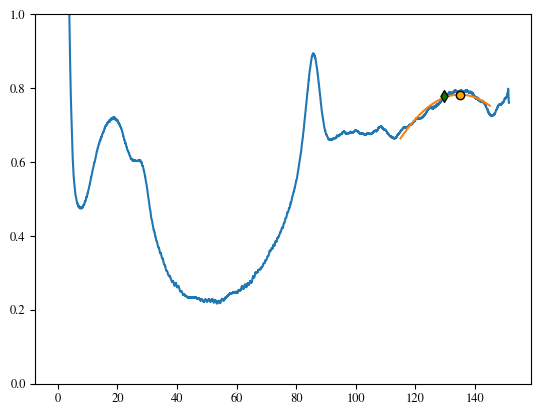

In [72]:
plt.plot(cap_vw_213,dva_vw_213)
Q,DVA = find_H2_peak(cap_vw_213,dva_vw_213,Q_min=115,Q_max=145)
plt.plot(Q,DVA)

maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA],marker="o",edgecolors="k",color="orange",zorder=3)

xpos, ypos = find_max_min(cap_vw_213, dva_vw_213, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="d",edgecolors="k",color="green",zorder=3)
plt.ylim(0,1)

(0.0, 1.0)

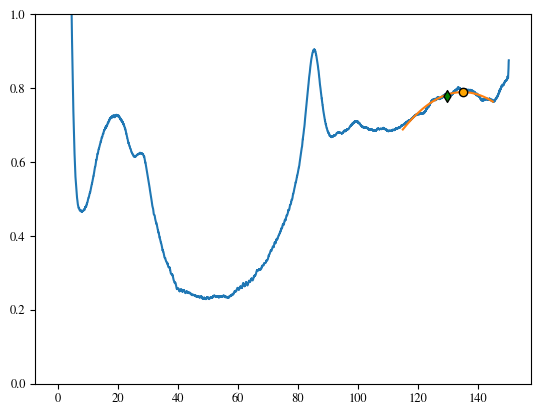

In [73]:
plt.plot(cap_vw_204,dva_vw_204)
Q,DVA = find_H2_peak(cap_vw_204,dva_vw_204,Q_min=115,Q_max=145)
plt.plot(Q,DVA)

maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA],marker="o",edgecolors="k",color="orange",zorder=3)

xpos, ypos = find_max_min(cap_vw_213, dva_vw_213, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="d",edgecolors="k",color="green",zorder=3)

plt.ylim(0,1)

(0.0, 1.0)

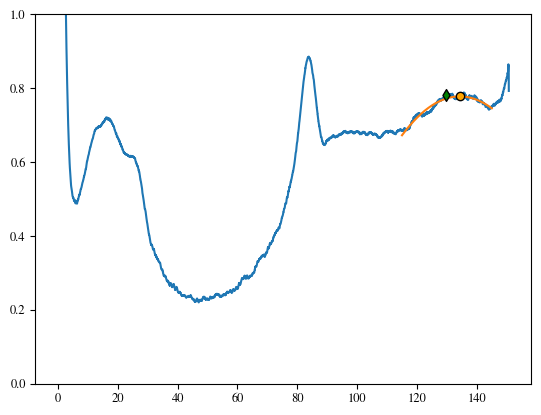

In [74]:
plt.plot(cap_vw_288,dva_vw_288)
Q,DVA = find_H2_peak(cap_vw_288,dva_vw_288,Q_min=115,Q_max=145)
plt.plot(Q,DVA)

maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA],marker="o",edgecolors="k",color="orange",zorder=3)

xpos, ypos = find_max_min(cap_vw_288,dva_vw_288, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="d",edgecolors="k",color="green",zorder=3)


plt.ylim(0,1)

(0.0, 1.0)

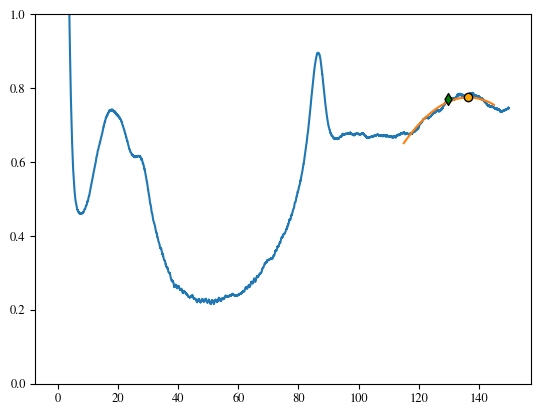

In [75]:
plt.plot(cap_vw_349,dva_vw_349)
Q,DVA = find_H2_peak(cap_vw_349,dva_vw_349,Q_min=115,Q_max=145)
plt.plot(Q,DVA)

maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA],marker="o",edgecolors="k",color="orange",zorder=3)

xpos, ypos = find_max_min(cap_vw_349,dva_vw_349, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="d",edgecolors="k",color="green",zorder=3)


plt.ylim(0,1)

(0.0, 1.0)

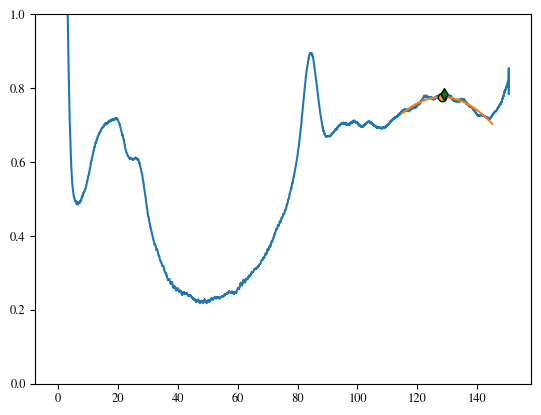

In [76]:
plt.plot(cap_vw_397,dva_vw_397)
Q,DVA = find_H2_peak(cap_vw_397,dva_vw_397,Q_min=115,Q_max=145)
plt.plot(Q,DVA)

maxDVA = np.argmax(DVA)
plt.scatter(Q[maxDVA],DVA[maxDVA],marker="o",edgecolors="k",color="orange",zorder=3)

xpos, ypos = find_max_min(cap_vw_397,dva_vw_397, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="d",edgecolors="k",color="green",zorder=3)


plt.ylim(0,1)